
---

# Assignment: Recovery Rate Investigation

Using the **SIRD model** implemented during the practical, this section investigates how changing the recovery rate, γ, changes epidemic outcomes. The assignment-specified basic reproduction number is calculated as **R_0 = β/γ**.


In [ ]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# SIRD function from the tutorial:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y
    N = S + I + R + D

    # SIRD differential equations
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

## Part 1: Parameter analysis function

The function below tests `gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]`, records the required epidemic metrics, returns them as a `pandas.DataFrame`, and plots all infectious curves on one publication-quality figure.

For each recovery rate, the following epidemic outcomes are calculated:

- Peak number of infectious individuals
- Day on which the infection peak occurs
- Total deaths at the end of the simulation
- Basic reproduction number, R₀ = β / γ


In [ ]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    gamma_v = [0.05, 0.1, 0.15, 0.2, 0.25]
    t = np.linspace(0, simulation_days - 1, simulation_days)
    results = []

    fig, ax = plt.subplots(figsize=(10, 6))

    for gamma in gamma_v:
        # Initial SIRD
        y0 = [N - I0, I0, 0, 0]
        sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = sol.T

        #metrics
        peak_infected = np.max(I)
        peak_day = int(np.argmax(I))
        total_deaths = D[-1]
        R0 = beta / gamma

        results.append({
            'gamma': gamma,
            'R0': R0,
            'peak_infected': peak_infected,
            'peak_day': peak_day,
            'total_deaths': total_deaths
        })

        ax.plot(t, I, linewidth=2,
                label=f'γ={gamma:.2f} (R_0={R0:.2f})')

    # plot
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Infectious individuals')
    ax.set_title(
        f'Effect of Recovery Rate on Epidemic Curves '
        f'(β={beta}, μ={mu}, N={N})'
    )
    ax.legend(title='Recovery rate', frameon=True)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()

    #Convert data to panda Dataframe
    results_df = pd.DataFrame(
        results,
        columns=['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths']
    )
    # Formatting
    return results_df.round({
        'gamma': 2,
        'R0': 2,
        'peak_infected': 1,
        'total_deaths': 1
    })



## Part 1.2 and 1.3: Recovery Rate Analysis

The function tests the following recovery rates, based on the SIRD model from the practical:

γ = [0.05, 0.10, 0.15, 0.20, 0.25]

SIRD parameters from Part 3 of the practical:

- β = 0.3
- μ = 0.01
- N = 1000
- Initial infected = 10
- Simulation duration = 150 days





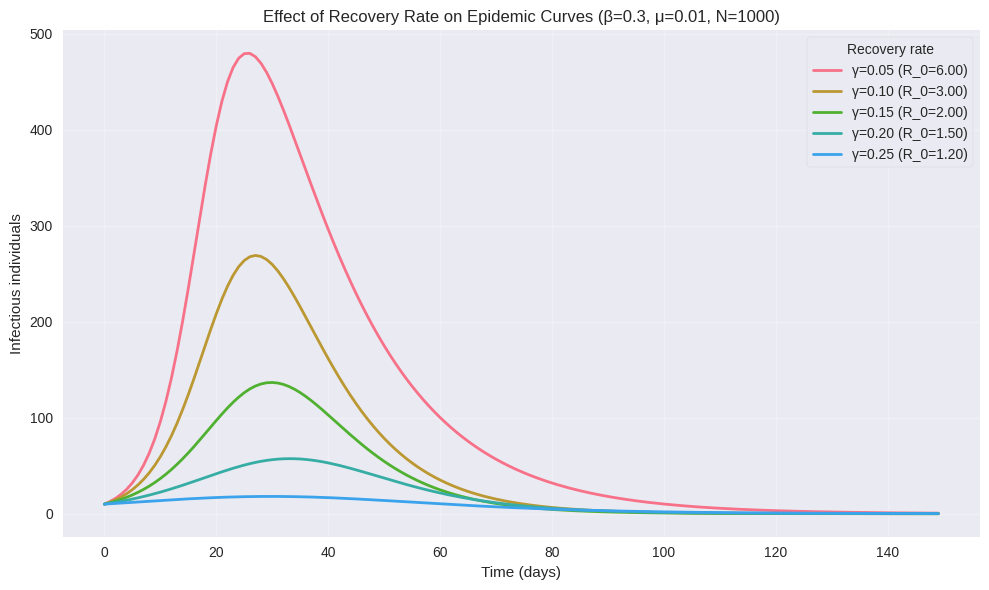

   gamma   R0  peak_infected  peak_day  total_deaths
0   0.05  6.0     479.737984        26    165.413925
1   0.10  3.0     269.138176        27     83.572705
2   0.15  2.0     136.756407        30     47.712503
3   0.20  1.5      57.359889        33     26.019199
4   0.25  1.2      18.021355        30     11.436114
Recovery results


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,479.7,26,165.4
1,0.10,3.0,269.1,27,83.6
2,0.15,2.0,136.8,30,47.7
3,0.20,1.5,57.4,33,26.0
4,0.25,1.2,18.0,30,11.4


In [ ]:
recovery_results = analyze_recovery_rates(
    beta=0.3,
    mu=0.01,
    N=1000,
    I0=10,
    simulation_days=150
)
print("Recovery results")
display(recovery_results)

## Part 2: Scenario comparison

### Scenario A — High Transmission
`beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200`

### Scenario B — Low Transmission
`beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200`


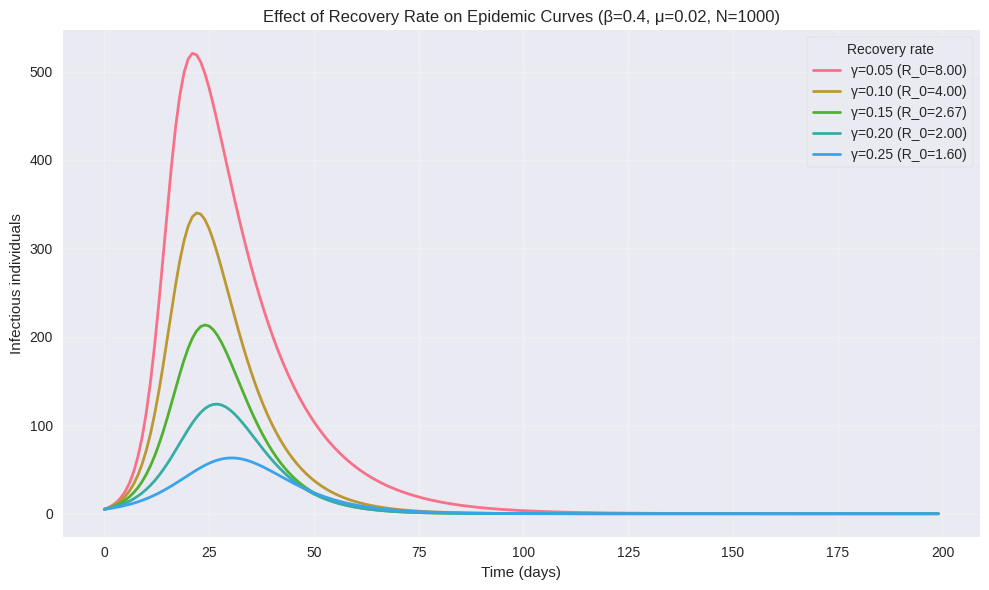

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  8.000000     520.582635        21    284.757361
1   0.10  4.000000     340.140583        22    159.892366
2   0.15  2.666667     213.465894        24    102.610885
3   0.20  2.000000     123.893909        27     67.423926
4   0.25  1.600000      63.051893        30     42.694003
Scenario A - High Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.6,21,284.8
1,0.10,4.00,340.1,22,159.9
2,0.15,2.67,213.5,24,102.6
3,0.20,2.00,123.9,27,67.4
4,0.25,1.60,63.1,30,42.7


In [ ]:
# Run Scenario A - High Transmission
scenario_A_results = analyze_recovery_rates(
    beta=0.4,
    mu=0.02,
    N=1000,
    I0=5,
    simulation_days=200
)

print("Scenario A - High Transmission")
display(scenario_A_results)


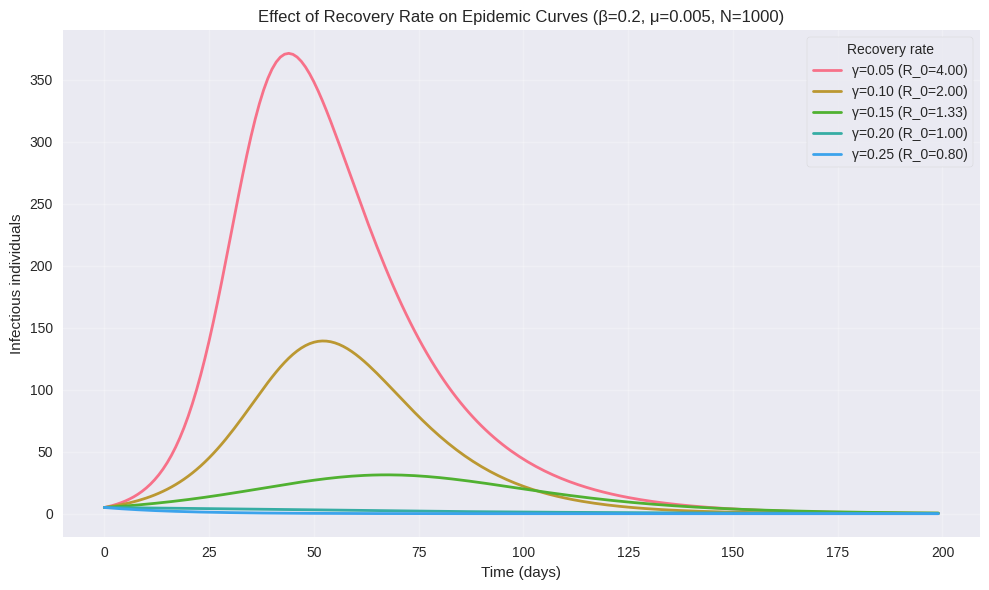

Scenario B - Low Transmission


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.4,44,88.2
1,0.10,2.00,139.3,52,36.7
2,0.15,1.33,31.3,67,13.6
3,0.20,1.00,5.0,0,1.8
4,0.25,0.80,5.0,0,0.4


In [ ]:
# Run Scenario B - Low Transmission
scenario_B_results = analyze_recovery_rates(
    beta=0.2,
    mu=0.005,
    N=1000,
    I0=5,
    simulation_days=200
)

print("Scenario B - Low Transmission")
display(scenario_B_results)


### Comparative visualization

The plots below compare the two scenarios across recovery rates using two public-health outcomes: peak infectious population and final deaths.


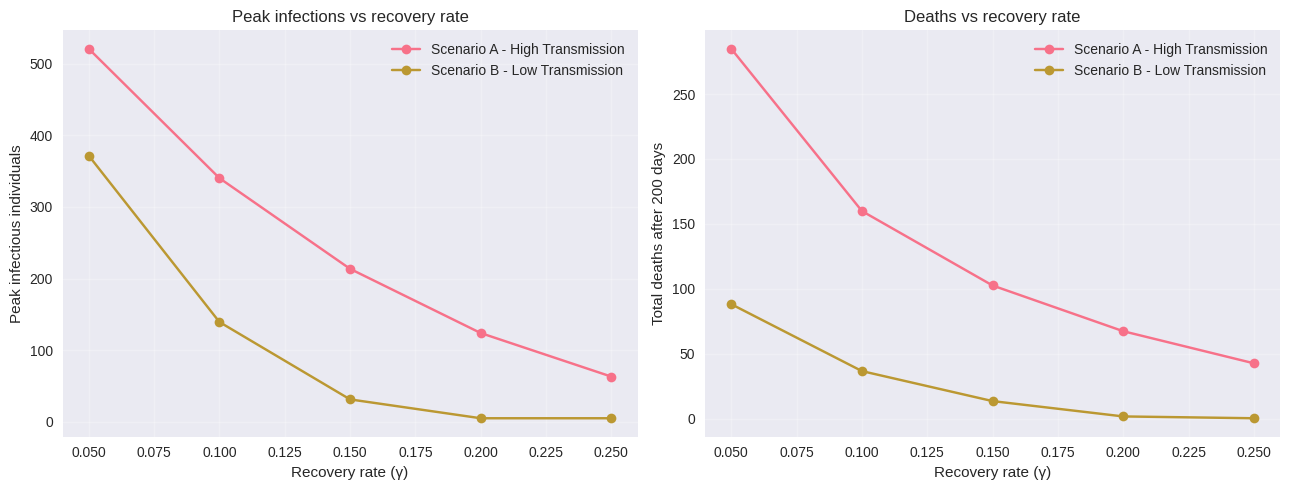

In [ ]:

# side by side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Comparison plots.
# Peak infections vs Recovery rate of A and B
axes[0].plot(
    scenario_A_results['gamma'], scenario_A_results['peak_infected'],
    marker='o', label='Scenario A - High Transmission'
)
axes[0].plot(
    scenario_B_results['gamma'], scenario_B_results['peak_infected'],
    marker='o', label='Scenario B - Low Transmission'
)
axes[0].set_xlabel('Recovery rate (γ)')
axes[0].set_ylabel('Peak infectious individuals')
axes[0].set_title('Peak infections vs Recovery rate')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

# Comapring Death and recovery rate A and B
axes[1].plot(
    scenario_A_results['gamma'], scenario_A_results['total_deaths'],
    marker='o', label='Scenario A - High Transmission'
)
axes[1].plot(
    scenario_B_results['gamma'], scenario_B_results['total_deaths'],
    marker='o', label='Scenario B - Low Transmission'
)
axes[1].set_xlabel('Recovery rate (γ)')
axes[1].set_ylabel('Total deaths after 200 days')
axes[1].set_title('Deaths vs Recovery rate')
axes[1].grid(True, alpha=0.25)
axes[1].legend()


fig.tight_layout()
plt.show()


### Scenario analysis

**Scenario A is worse for public health across all  recovery rates.**

It combines a higher transmission rate (`β=0.4` versus `0.2`) with a higher mortality rate (`μ=0.02` versus `0.005`). For example, at γ=0.10, Scenario A has R_0=4.00, a peak of about 340.1 infectious people on day 22, and about 159.9 deaths by day 200. Scenario B at the same recovery rate has R_0=2.00, a peak of about 139.3 infectious people on day 52, and about 36.7 deaths. Therefore Scenario A has a larger and earlier peak and many more deaths at the recovery rate. Increasing γ improves both scenarios because infectious individuals stop being infected faster. Meaning that there is less time for infected individuals to infect others.


## Part 3: Policy recommendations

### 3.1 Parameter impact analysis

How does increasing recovery rate affect peak infections, total deaths, and epidemic duration?

Increasing the recovery rate strongly reduces the impact of the epidemic. In **Scenario A**, raising γ from 0.05 to 0.25 reduces the peak infectious population from about 520.6 to 63.1 and reduces total deaths by about 242. The peak also moves from day 21 to day 30, meaning that faster recovery both flattens the  curve and delays the peak.



### 3.2 Intervention analysis

In [ ]:
# Quantify a 50% increase in recovery rate for Scenario A.
# Baseline gamma = 0.10, so a 50% increase gives gamma = 0.15.
baseline_gamma = 0.10
improved_gamma = 0.15

baseline = scenario_A_results.loc[np.isclose(scenario_A_results['gamma'], baseline_gamma)].iloc[0]
improved = scenario_A_results.loc[np.isclose(scenario_A_results['gamma'], improved_gamma)].iloc[0]

# calculations from the SIRD
deaths_prevented = baseline['total_deaths'] - improved['total_deaths']
percent_death_reduction = deaths_prevented / baseline['total_deaths'] * 100
peak_reduction = baseline['peak_infected'] - improved['peak_infected']
percent_peak_reduction = peak_reduction / baseline['peak_infected'] * 100

# printing analysis numbers
print(f"Baseline γ: {baseline_gamma:.2f}")
print(f"50% higher γ: {improved_gamma:.2f}")
print(f"Deaths at baseline: {baseline['total_deaths']:.1f}")
print(f"Deaths after intervention: {improved['total_deaths']:.1f}")
print(f"Deaths prevented: {deaths_prevented:.1f}")
print(f"Percentage reduction in deaths: {percent_death_reduction:.1f}%")
print(f"Peak infections reduced by: {peak_reduction:.1f} ({percent_peak_reduction:.1f}%)")


Baseline γ: 0.10
50% higher γ: 0.15
Deaths at baseline: 159.9
Deaths after intervention: 102.6
Deaths prevented: 57.3
Percentage reduction in deaths: 35.8%
Peak infections reduced by: 126.6 (37.2%)




Using Scenario A with γ=0.10 as the baseline, a 50% improvement in recovery rate gives:

- Baseline recovery rate: γ = 0.10
- Improved recovery rate: γ = 0.15
- Baseline deaths: 159.9
- Deaths with improved recovery: 102.6
- Deaths prevented: 159.9 − 102.6 = 57.3
- Percentage reduction: 57.3 / 159.9 × 100 ≈ 35.8%

The model therefore predicts that this 50% increase in γ would prevent around 57 deaths per  1,000 people in  Scenario A over  200 days using the simulation. Peak infections also fall from around 340.1 to 213.5, a reduction of around 37.2%.


### 3.3 Real-world application


Antiviral medication is a medical intervention and common treatment used to speed up recovery rates. They work by inhibiting a virus’s ability to replicate and can therefore shorten a patient's time to recover. An example of an antiviral medication would be Sofosbuvir, Sofosbuvir has a broad antiviral spectrum against many species of the Flaviviridae and Togaviridae families (including yellow fever, Zika, dengue, chikungunya, and hepatitis C viruses). According to the pooled meta-analysis of four randomized controlled trials (RCTs), a Sofosbuvir based regimen significantly increased clinical recovery rates by 20% compared to standard care or alternative treatment.

Rate Ratio (RR): 1.20 (95% CI: 1.04–1.38).

In individual trials, it also demonstrated:

Lower mortality: RR 0.31 (95% CI: 0.12–0.78).

Fewer ICU admissions: RR 0.33 (95% CI: 0.15–0.72).

Shorter hospital stays: Reduced from 8 to 6 days (p = 0.029) in moderate/severe COVID-19, and from 9 to 5 days (p < 0.01) compared to ribavirin in severe cases.

Data from:
Lai, C.-C., Chao, C.-M., & Hsueh, P.-R. (2021). Clinical efficacy of antiviral agents against coronavirus disease 2019: A systematic review of randomized controlled trials. Journal of Microbiology, Immunology and Infection, 54(5), 767–775. https://doi.org/10.1016/j.jmii.2021.05.011










